# Causal Inference Examples

## Simpson's paradox

In [1]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import CausalInference

from pgmpy.global_vars import config
config.set_backend('numpy')

c:\dev\pgmpy\pgmpy-eu-summer-of-code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\dev\pgmpy\pgmpy-eu-summer-of-code\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [4]:
# Define Simpson's Paradox causal model
simp_model = DiscreteBayesianNetwork([("S", "T"), ("T", "C"), ("S", "C")])

# Create CPDs
cpd_s = TabularCPD(
    variable="S", variable_card=2, values=[[0.5], [0.5]], state_names={"S": ["m", "f"]}
)
cpd_t = TabularCPD(
    variable="T",
    variable_card=2,
    values=[[0.25, 0.75], [0.75, 0.25]],
    evidence=["S"],
    evidence_card=[2],
    state_names={"S": ["m", "f"], "T": [0, 1]},
)
cpd_c = TabularCPD(
    variable="C",
    variable_card=2,
    values=[[0.3, 0.4, 0.7, 0.8], [0.7, 0.6, 0.3, 0.2]],
    evidence=["S", "T"],
    evidence_card=[2, 2],
    state_names={"S": ["m", "f"], "T": [0, 1], "C": [0, 1]},
)

# Add CPDs to model
simp_model.add_cpds(cpd_s, cpd_t, cpd_c)
print("✓ Simpson's Paradox model defined")

✓ Simpson's Paradox model defined


### Model Definition

In [5]:
from pgmpy.examples_utils import VisualizationHelper

# Visualize the causal model
viz_file = VisualizationHelper.visualize_graph(simp_model, output_file='simpson_paradox.png')
if viz_file:
    VisualizationHelper.display_image(viz_file)
else:
    print("Model structure created. Visualization unavailable - continuing with causal inference...")

2026-03-31 10:25:56,748 - pgmpy.examples_utils - WARNING - ⚠ pygraphviz not installed. Install with: pip install pygraphviz


Model structure created. Visualization unavailable - continuing with causal inference...


In [ ]:
# Already defined in previous cell - model is ready for inference
print("\n" + "="*60)
print("Simpson's Paradox Model is ready")
print("="*60)

NameError: name 'simp_model' is not defined

### Inference conditioning on T

In [6]:
from pgmpy.examples_utils import InferenceWrapper

# Non-adjusted inference (standard conditioning)
infer_non_adjust = InferenceWrapper(simp_model, inference_class='VariableElimination')

print("="*60)
print("NON-ADJUSTED INFERENCE: P(C|T)")
print("="*60)
print("\nP(C | T=1):")
result1 = infer_non_adjust.query(variables=["C"], evidence={"T": 1})
if result1 is not None:
    print(result1)

print("\nP(C | T=0):")
result2 = infer_non_adjust.query(variables=["C"], evidence={"T": 0})
if result2 is not None:
    print(result2)
print("="*60)

2026-03-31 10:25:59,880 - pgmpy.examples_utils - INFO - ✓ Initialized VariableElimination
2026-03-31 10:25:59,883 - pgmpy.examples_utils - INFO - ✓ Query successful for ['C']
2026-03-31 10:25:59,886 - pgmpy.examples_utils - INFO - ✓ Query successful for ['C']


NON-ADJUSTED INFERENCE: P(C|T)

P(C | T=1):
+------+----------+
| C    |   phi(C) |
+======+==========+
| C(0) |   0.5000 |
+------+----------+
| C(1) |   0.5000 |
+------+----------+

P(C | T=0):
+------+----------+
| C    |   phi(C) |
+======+==========+
| C(0) |   0.6000 |
+------+----------+
| C(1) |   0.4000 |
+------+----------+


### Inference with do-operation on T

In [7]:
from pgmpy.examples_utils import CausalInferenceWrapper

# Causal inference with do-calculus
infer_causal = CausalInferenceWrapper(simp_model)

print("\n" + "="*60)
print("CAUSAL INFERENCE: P(C | do(T))")
print("="*60)
print("\nP(C | do(T=1)) - treatment effect of T=1:")
result_do1 = infer_causal.do_query(variables=["C"], do_values={"T": 1})
if result_do1 is not None:
    print(result_do1)

print("\nP(C | do(T=0)) - treatment effect of T=0:")
result_do0 = infer_causal.do_query(variables=["C"], do_values={"T": 0})
if result_do0 is not None:
    print(result_do0)
print("="*60)

2026-03-31 10:26:03,337 - pgmpy.examples_utils - INFO - ✓ Initialized CausalInference



CAUSAL INFERENCE: P(C | do(T))

P(C | do(T=1)) - treatment effect of T=1:


100%|██████████| 2/2 [00:00<00:00, 1994.91it/s]
2026-03-31 10:26:03,355 - pgmpy.examples_utils - INFO - ✓ Do-query successful: do({'T': 1}) -> ['C']


+------+----------+
| C    |   phi(C) |
+======+==========+
| C(0) |   0.6000 |
+------+----------+
| C(1) |   0.4000 |
+------+----------+

P(C | do(T=0)) - treatment effect of T=0:


100%|██████████| 2/2 [00:00<00:00, 2000.14it/s]
2026-03-31 10:26:03,361 - pgmpy.examples_utils - INFO - ✓ Do-query successful: do({'T': 0}) -> ['C']


+------+----------+
| C    |   phi(C) |
+======+==========+
| C(0) |   0.5000 |
+------+----------+
| C(1) |   0.5000 |
+------+----------+


## Specifying adjustment sets

<Axes: >

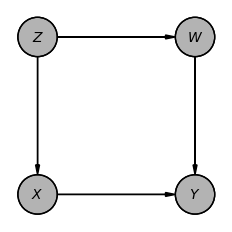

In [ ]:
from pgmpy.examples_utils import VisualizationHelper

model = DiscreteBayesianNetwork([("X", "Y"), ("Z", "X"), ("Z", "W"), ("W", "Y")])
cpd_z = TabularCPD(variable="Z", variable_card=2, values=[[0.2], [0.8]])

cpd_x = TabularCPD(
    variable="X",
    variable_card=2,
    values=[[0.1, 0.3], [0.9, 0.7]],
    evidence=["Z"],
    evidence_card=[2],
)

cpd_w = TabularCPD(
    variable="W",
    variable_card=2,
    values=[[0.2, 0.9], [0.8, 0.1]],
    evidence=["Z"],
    evidence_card=[2],
)

cpd_y = TabularCPD(
    variable="Y",
    variable_card=2,
    values=[[0.3, 0.4, 0.7, 0.8], [0.7, 0.6, 0.3, 0.2]],
    evidence=["X", "W"],
    evidence_card=[2, 2],
)

model.add_cpds(cpd_z, cpd_x, cpd_w, cpd_y)

# Visualize
viz_file = VisualizationHelper.visualize_graph(model, output_file='adjustment_example.png')
if viz_file:
    VisualizationHelper.display_image(viz_file)
else:
    print("Model structure created. Visualization unavailable - continuing with causal analysis...")

In [ ]:
# Do operation with specified adjustment set
infer = CausalInferenceWrapper(model)

print("\n" + "="*60)
print("ADJUSTMENT SET EXAMPLE: P(Y | do(X), adjust for [Z, W])")
print("="*60)

# Causal effect of X on Y with adjustment
result_adjusted = infer.do_query(variables=["Y"], do_values={"X": 1})
if result_adjusted is not None:
    print("\nP(Y | do(X=1)) with adjustment:")
    print(result_adjusted)
else:
    print("Could not compute adjusted causal effect")
print("="*60)

  0%|          | 0/2 [00:00<?, ?it/s]

+------+----------+
| Y    |   phi(Y) |
+======+==========+
| Y(0) |   0.7240 |
+------+----------+
| Y(1) |   0.2760 |
+------+----------+


  0%|          | 0/2 [00:00<?, ?it/s]

+------+----------+
| Y    |   phi(Y) |
+======+==========+
| Y(0) |   0.7240 |
+------+----------+
| Y(1) |   0.2760 |
+------+----------+


  0%|          | 0/4 [00:00<?, ?it/s]

+------+----------+
| Y    |   phi(Y) |
+======+==========+
| Y(0) |   0.7240 |
+------+----------+
| Y(1) |   0.2760 |
+------+----------+


  0%|          | 0/2 [00:00<?, ?it/s]

+------+----------+
| C    |   phi(C) |
+======+==========+
| C(0) |   0.6000 |
+------+----------+
| C(1) |   0.4000 |
+------+----------+


In [8]:
# Adjustment without do operation.
infer = CausalInference(model)
adj_W = infer.query(["Y"], adjustment_set=["W"])
print(adj_W)

adj_Z = infer.query(["Y"], adjustment_set=["Z"])
print(adj_Z)

adj_WZ = infer.query(["Y"], adjustment_set=["W", "Z"])
print(adj_WZ)

infer_simp = CausalInference(simp_model)
adj_simpson = infer_simp.query(["C"], adjustment_set=["S"])
print(adj_simpson)

+------+----------+
| Y    |   phi(Y) |
+======+==========+
| Y(0) |   0.6200 |
+------+----------+
| Y(1) |   0.3800 |
+------+----------+
+------+----------+
| Y    |   phi(Y) |
+======+==========+
| Y(0) |   0.6200 |
+------+----------+
| Y(1) |   0.3800 |
+------+----------+
+------+----------+
| Y    |   phi(Y) |
+======+==========+
| Y(0) |   0.6200 |
+------+----------+
| Y(1) |   0.3800 |
+------+----------+
+------+----------+
| C    |   phi(C) |
+======+==========+
| C(0) |   0.5500 |
+------+----------+
| C(1) |   0.4500 |
+------+----------+
